# Spike Train Analysis Workflow

Comprehensive walkthrough of the **sta** submodule, covering firing-rate
statistics, temporal structure, trial reliability, and response latency.

## 1. Setup & Synthetic Data

We generate two-cluster spike trains via a Poisson process at 25 kHz (0.04 ms bins).
Cluster 1 fires at a flat 5 Hz (orientation-indifferent); cluster 2 peaks at 10 Hz
with Gaussian tuning (σ = 15°, preferred 90°). Both share a 0.5 Hz spontaneous baseline.

In [1]:
%matplotlib inline
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from neural_cca import load_from_arrays, steps2degree

print("Imports successful")

Imports successful


In [ ]:
# ---------------------------------------------------------------------------
# Synthetic two-unit dataset.
#
# ``make_two_unit_demo`` builds the canonical demo used across every
# example notebook: one orientation-indifferent cluster + one
# orientation-selective cluster, with bin-wise inhomogeneous Poisson
# spike trains (1 ms absolute refractory) and Gaussian-template
# waveform snippets, all packaged into a ``SortingData`` container.
# The same helper backs ``tests/conftest.py``\'s spike fixtures, so
# example and test data live in lockstep.
# ---------------------------------------------------------------------------
from neural_cca.synthetic import make_two_unit_demo

demo = make_two_unit_demo(seed=42)

# Expose the legacy variable names downstream cells still reference.
spike_times_c1, trials_c1 = demo.spike_times_c1, demo.trials_c1
spike_times_c2, trials_c2 = demo.spike_times_c2, demo.trials_c2
spike_times = demo.spike_times
trials = demo.trials
waveforms = demo.waveforms
ground_truth = demo.ground_truth
angles = demo.angles
n_trials = demo.n_trials
c2_pref_ori = demo.c2_pref_ori
c2_sigma = demo.c2_sigma
rng = demo.rng

print(f"Cluster 1 (indifferent): {len(spike_times_c1)} spikes")
print(f"Cluster 2 (selective):   {len(spike_times_c2)} spikes")

In [ ]:
# ``make_two_unit_demo`` already merged + chronologically sorted the
# two clusters and packaged them as a ``SortingData`` container; we
# just hand it to the rest of the pipeline.
data = demo.sorting_data
print(f"Merged: {len(spike_times)} spikes | SortingData loaded")

In [4]:
from neural_cca import run_sorting_pipeline

result = run_sorting_pipeline(
    data,
    preprocess="zscore_pca",  # z-score → PCA → KMeans (default)
    pca_components=0.95,
    plot=False,
)
labels = result.cluster_labels
print(f"Sorting found {result.n_clusters} clusters")

Sorting found 2 clusters


## 2. Basic Spike Train Statistics

The most fundamental characterisation of a neuron's activity is its firing rate and
ISI variability. Mean firing rate (MFR) tells us how active the neuron is; the
coefficient of variation (CV) indicates temporal regularity (CV = 1 for Poisson,
< 1 for regular, > 1 for bursty); and the local variation revised (LvR) captures
variability while being robust to slow rate changes.

In [5]:
from neural_cca import minimal_spike_train_analysis

# Pass ``trials`` so CV and LvR are computed from within-trial ISIs
# only — without it, cross-trial spike pairs leak in as fake ISIs and
# bias both metrics (LvR especially).
for cl in range(result.n_clusters):
    stats = minimal_spike_train_analysis(
        spike_times,
        trials=trials,
        cluster_labels=labels,
        cluster_id=cl,
        n_trials=data.n_trials,
        stim_window=data.stim_window,
    )
    print(f"Cluster {cl}:")
    pprint(stats)
    print()

Cluster 0:
{'cv': 1.4649763571118475, 'lvr': 1.0523722120267693, 'mfr': 3.1136690647482013}

Cluster 1:
{'cv': 1.000986627741877, 'lvr': 1.0548250852069518, 'mfr': 4.083333333333333}



## 3. ISI Distribution & Violations

The interspike interval (ISI) distribution reveals fine temporal structure of neural
firing. A key quality check is the refractory period: biological neurons cannot fire
within ~1 ms of a previous spike. Violations suggest noise contamination or that the
cluster contains spikes from multiple neurons.

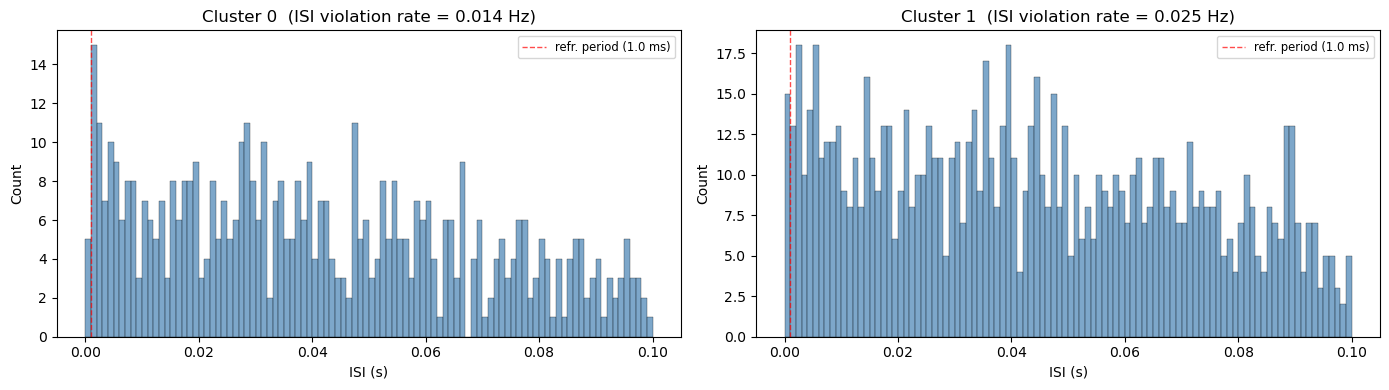

In [6]:
from neural_cca import plot_isi_histogram, isi_violation_rate

# ``isi_violation_rate`` needs ``trials`` + ``trial_duration`` for
# trial-based recordings.  Without them it would treat the
# trial-relative spike train as one continuous recording, count
# inter-trial spike pairs as ISI violations, and divide by the
# trial-window size instead of the total recording duration —
# inflating the rate by ~n_trials and producing nonsense numbers
# (e.g. 600 Hz for a 4 Hz cell).
trial_dur = data.stim_window[1]  # full trial length, not just stim window

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cl, ax in enumerate(axes):
    cl_mask = labels == cl
    plot_isi_histogram(spike_times[cl_mask], trials=trials[cl_mask], ax=ax)
    viol = isi_violation_rate(
        spike_times,
        trials=trials,
        cluster_labels=labels,
        cluster_id=cl,
        trial_duration=trial_dur,
    )
    ax.set_title(f"Cluster {cl}  (ISI violation rate = {viol:.3f} Hz)")
plt.tight_layout()
plt.show()
plt.close("all")

## 4. Autocorrelogram

The autocorrelogram (ACG) shows the probability of observing a spike at various time
lags relative to any given spike. It reveals rhythmic patterns (oscillatory bumps),
bursting (peak near zero lag), and the refractory gap at very short lags. For
Poisson-like firing the ACG is flat.

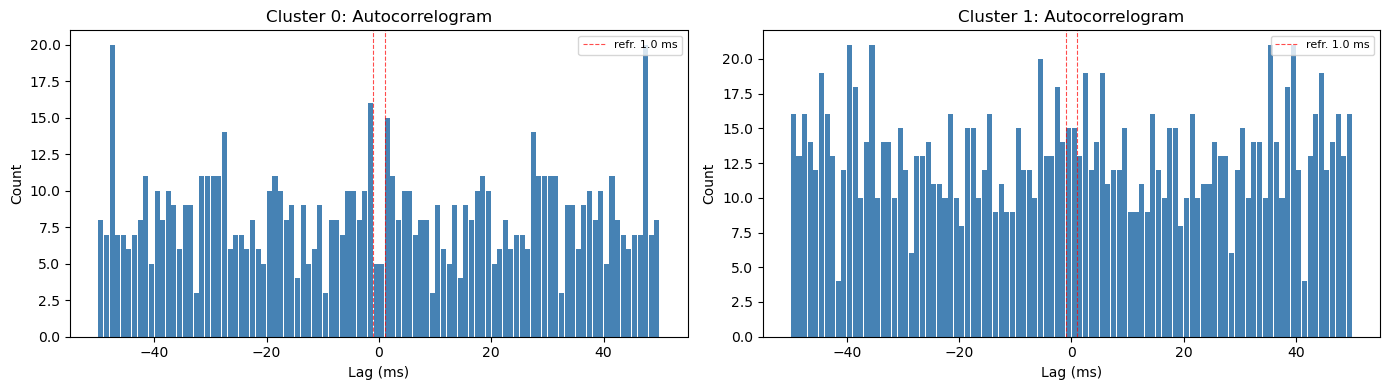

In [7]:
from neural_cca import plot_autocorrelogram

# Pass ``trials`` so the ACG accumulates pairs *within each trial only*.
# Without it, the global sort merges spikes from different trials and
# the histogram becomes the autocorrelation of the trial structure
# (every cross-trial pair within max_lag is added), washing out the
# real refractory dip and burst pattern and inflating bin counts by
# roughly n_trials.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cl, ax in enumerate(axes):
    plot_autocorrelogram(
        spike_times,
        trials=trials,
        cluster_labels=labels,
        cluster_id=cl,
        bin_size=0.001,
        max_lag=0.05,
        ax=ax,
    )
    ax.set_title(f"Cluster {cl}: Autocorrelogram")
plt.tight_layout()
plt.show()
plt.close("all")

## 5. Peri-Stimulus Time Histogram (PSTH)

The PSTH averages spike counts across trials to reveal the time course of neural
responses relative to stimulus onset. It is the workhorse visualisation for sensory
neuroscience: a stimulus-locked increase in firing rate indicates a driven response.
Varying the bin size trades temporal resolution against noise.

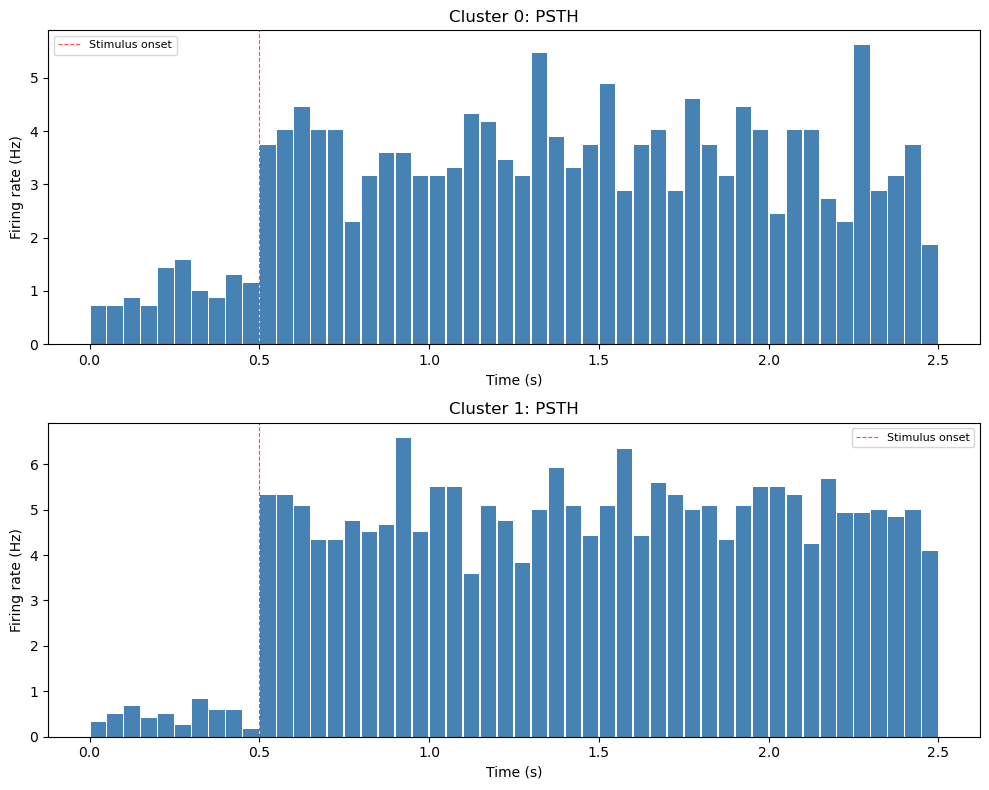

In [8]:
from neural_cca import plot_psth

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for cl, ax in enumerate(axes):
    plot_psth(
        spike_times,
        trials,
        cluster_labels=labels,
        cluster_id=cl,
        bin_size=0.05,
        trial_duration=data.stim_window[1],
        stim_onset=data.stim_window[0],
        ax=ax,
    )
    ax.set_title(f"Cluster {cl}: PSTH")
plt.tight_layout()
plt.show()
plt.close("all")

## 6. Spike Raster

A spike raster plots individual spike times per trial, giving a trial-by-trial view
of the raw data lost in the PSTH average. It reveals trial-to-trial variability,
response onset reliability, and potential non-stationarities across the session.

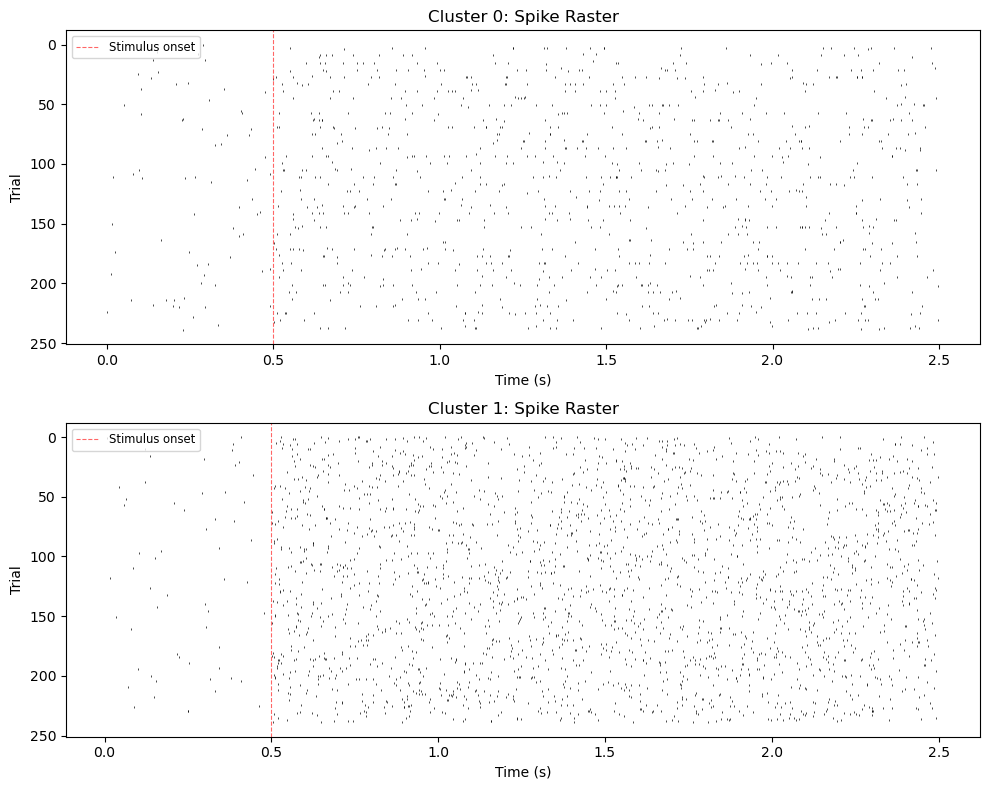

In [9]:
from neural_cca import plot_spike_raster

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for cl, ax in enumerate(axes):
    cl_mask = labels == cl
    plot_spike_raster(spike_times[cl_mask], trials[cl_mask], stim_onset=data.stim_window[0], ax=ax)
    ax.set_title(f"Cluster {cl}: Spike Raster")
plt.tight_layout()
plt.show()
plt.close("all")

## 7. Firing Rate Stability

Neural recordings can drift over time due to electrode movement, tissue changes, or
adaptation. Monitoring how the firing rate evolves across time windows reveals these
non-stationarities. A high coefficient of variation across windows flags sessions
where rate changes could confound stimulus-response comparisons.

Cluster 0: mean=3.11, CV=0.340
Cluster 1: mean=4.08, CV=0.442


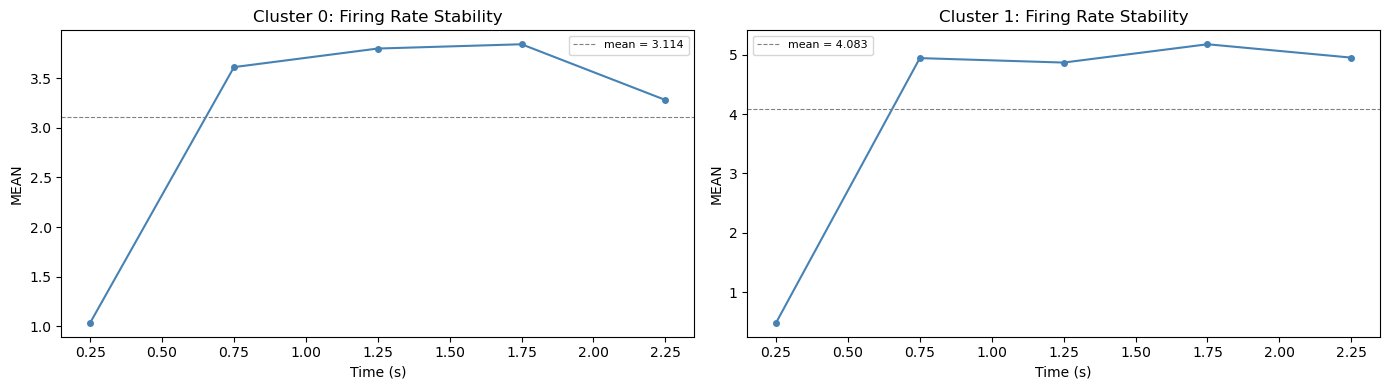

In [10]:
from neural_cca import firing_rate_stability, plot_firing_rate_stability

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cl, ax in enumerate(axes):
    plot_firing_rate_stability(
        spike_times, trials, cluster_labels=labels, cluster_id=cl, window_size=0.5, ax=ax
    )
    ax.set_title(f"Cluster {cl}: Firing Rate Stability")

    stab = firing_rate_stability(spike_times, trials, cluster_labels=labels, cluster_id=cl)
    print(f"Cluster {cl}: mean={stab['mean']:.2f}, CV={stab['cv_of_stat']:.3f}")
plt.tight_layout()
plt.show()
plt.close("all")

## 8. Fano Factor, Local Variation & CV of Log ISI

The Fano factor (variance/mean of spike counts) measures count variability: 1 for
Poisson, > 1 for bursty, < 1 for regular firing. Local variation (LV) captures
ISI-to-ISI regularity while being robust to slow rate fluctuations. The CV of
log ISI removes the rate dependence of the standard CV.

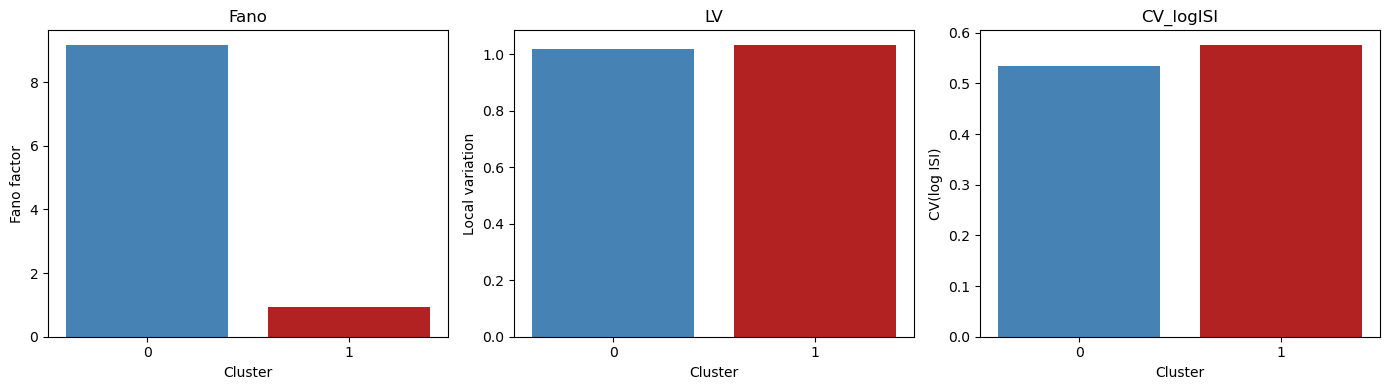

Cluster 0: {'Fano': 9.173313474913229, 'LV': 1.0161251573105077, 'CV_logISI': 0.5343004034715392}
Cluster 1: {'Fano': 0.9222789115646256, 'LV': 1.032111192846583, 'CV_logISI': 0.5757706845927288}


In [11]:
from neural_cca import fano_factor, local_variation, cv_log_isi

# Local variation and CV(log ISI) need ``trials`` for the same reason
# as ISI violation rate: cross-trial spike pairs would otherwise be
# treated as real ISIs.  ``fano_factor`` already uses an explicit
# per-trial mode.
metrics = {}
for cl in range(result.n_clusters):
    metrics[cl] = {
        "Fano": fano_factor(
            spike_times,
            trials=trials,
            cluster_labels=labels,
            cluster_id=cl,
            trial_duration=data.stim_window[1],
            mode="per_trial",
        ),
        "LV": local_variation(
            spike_times,
            trials=trials,
            cluster_labels=labels,
            cluster_id=cl,
        ),
        "CV_logISI": cv_log_isi(
            spike_times,
            trials=trials,
            cluster_labels=labels,
            cluster_id=cl,
        ),
    }

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (metric_name, ylabel) in enumerate(
    [("Fano", "Fano factor"), ("LV", "Local variation"), ("CV_logISI", "CV(log ISI)")]
):
    vals = [metrics[cl][metric_name] for cl in range(result.n_clusters)]
    axes[i].bar(range(result.n_clusters), vals, color=["steelblue", "firebrick"])
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(ylabel)
    axes[i].set_title(metric_name)
    axes[i].set_xticks(range(result.n_clusters))
plt.tight_layout()
plt.show()
plt.close("all")

for cl, m in metrics.items():
    print(f"Cluster {cl}: {m}")

## 9. First Spike Latency

The time from stimulus onset to the first evoked spike measures response timing.
Short, reliable latencies indicate prompt, consistent activation, whereas long or
variable latencies suggest weak drive. The latency distribution across trials
reveals whether the neuron is a reliable temporal encoder.

Cluster 0: mean=0.4092s, std=0.4458s, responsive=81.3%
Cluster 1: mean=0.1983s, std=0.2149s, responsive=100.0%


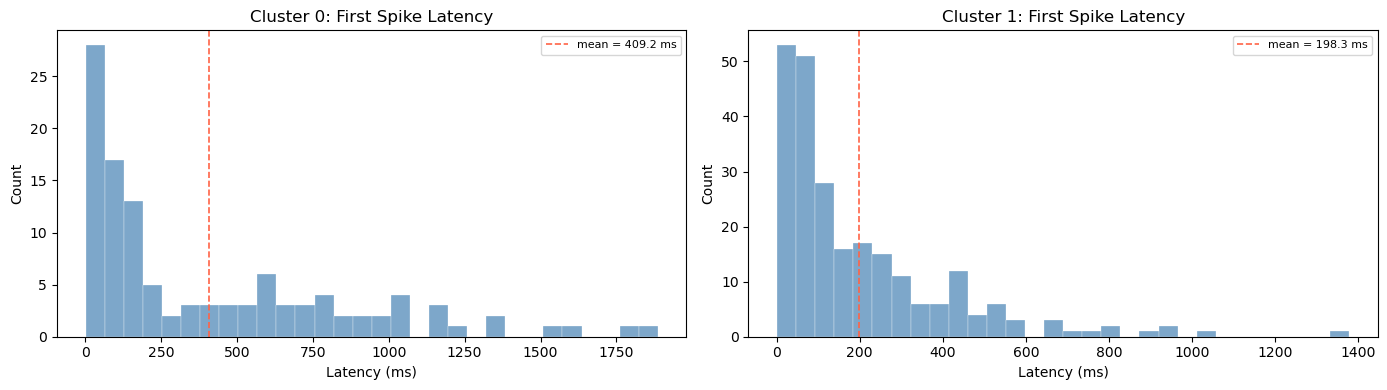

In [12]:
from neural_cca import first_spike_latency, plot_first_spike_latency

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cl, ax in enumerate(axes):
    plot_first_spike_latency(
        spike_times,
        trials,
        cluster_labels=labels,
        cluster_id=cl,
        stim_onset=data.stim_window[0],
        ax=ax,
    )
    ax.set_title(f"Cluster {cl}: First Spike Latency")

    fsl = first_spike_latency(
        spike_times, trials, cluster_labels=labels, cluster_id=cl, stim_onset=data.stim_window[0]
    )
    print(
        f"Cluster {cl}: mean={fsl['mean']:.4f}s, std={fsl['std']:.4f}s, "
        f"responsive={fsl['frac_responsive']:.1%}"
    )
plt.tight_layout()
plt.show()
plt.close("all")

## 10. Trial-to-Trial Reliability

Sensory neurons must reliably encode stimulus features across repeated presentations.
Trial-to-trial reliability measures response consistency, typically via pairwise
correlation of single-trial PSTHs. Multiple reliability metrics capture different
aspects: PSTH correlation (temporal pattern), MFR consistency (rate stability),
and Fano factor consistency (variability stability).

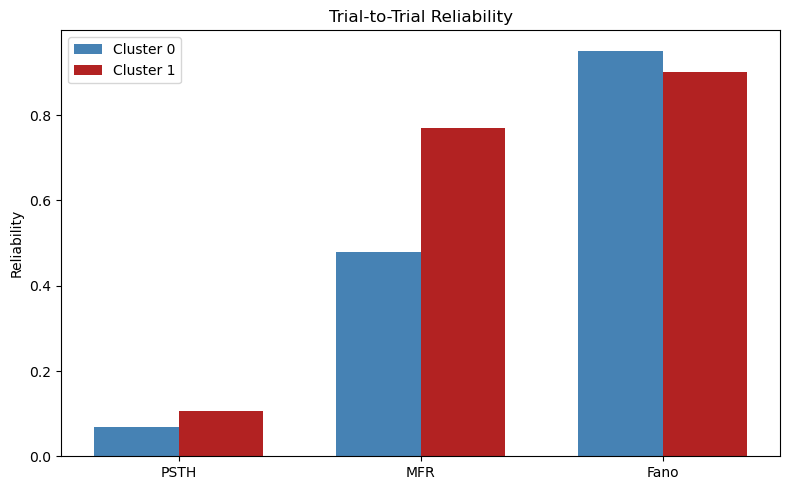

Cluster 0: {'PSTH': 0.06784987459561866, 'MFR': 0.4794857682483773, 'Fano': 0.9515003423814096}
Cluster 1: {'PSTH': 0.10736964713323527, 'MFR': 0.7688903302373655, 'Fano': 0.9003608648495076}


In [13]:
from neural_cca import trial_to_trial_reliability

reliability = {}
for cl in range(result.n_clusters):
    reliability[cl] = {
        "PSTH": trial_to_trial_reliability(
            spike_times, trials, cluster_labels=labels, cluster_id=cl, stat="psth"
        ),
        "MFR": trial_to_trial_reliability(
            spike_times, trials, cluster_labels=labels, cluster_id=cl, stat="mfr"
        ),
        "Fano": trial_to_trial_reliability(
            spike_times, trials, cluster_labels=labels, cluster_id=cl, stat="fano"
        ),
    }

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
w = 0.35
for i, cl in enumerate(range(result.n_clusters)):
    vals = [reliability[cl]["PSTH"], reliability[cl]["MFR"], reliability[cl]["Fano"]]
    ax.bar(x + i * w, vals, w, label=f"Cluster {cl}", color=["steelblue", "firebrick"][i])
ax.set_xticks(x + w / 2)
ax.set_xticklabels(["PSTH", "MFR", "Fano"])
ax.set_ylabel("Reliability")
ax.set_title("Trial-to-Trial Reliability")
ax.legend()
plt.tight_layout()
plt.show()
plt.close("all")

for cl, r in reliability.items():
    print(f"Cluster {cl}: {r}")

## 11. Trial Reliability Heatmap

While scalar metrics provide a summary, a heatmap of single-trial PSTHs reveals the
full structure of variability. Each row is one trial, each column a time bin; colour
intensity encodes firing rate. Consistent vertical bands indicate reliable, time-locked
responses; patchy patterns reveal trial-to-trial noise.

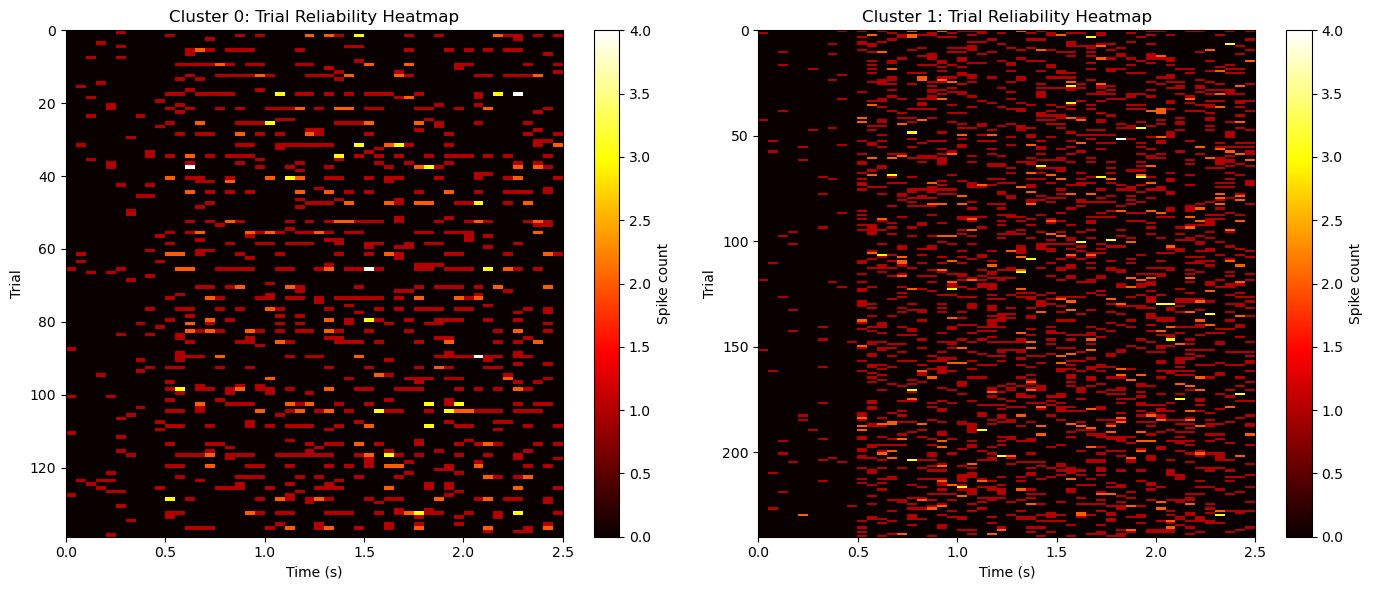

In [14]:
from neural_cca import plot_trial_reliability_heatmap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for cl, ax in enumerate(axes):
    plot_trial_reliability_heatmap(
        spike_times,
        trials,
        cluster_labels=labels,
        cluster_id=cl,
        bin_size=0.05,
        trial_duration=data.stim_window[1],
        ax=ax,
    )
    ax.set_title(f"Cluster {cl}: Trial Reliability Heatmap")
plt.tight_layout()
plt.show()
plt.close("all")

## 12. Cluster Comparison Summary

Side-by-side comparison of all spike-train metrics reveals the distinctive firing
properties of each neuron. The orientation-indifferent cluster should show uniform
firing, while the selective cluster should exhibit stimulus-dependent modulation.

In [15]:
from neural_cca import minimal_spike_train_analysis

summary = {}
for cl in range(result.n_clusters):
    basic = minimal_spike_train_analysis(
        spike_times,
        trials=trials,
        cluster_labels=labels,
        cluster_id=cl,
        n_trials=data.n_trials,
        stim_window=data.stim_window,
    )
    fsl = first_spike_latency(
        spike_times, trials, cluster_labels=labels, cluster_id=cl, stim_onset=data.stim_window[0]
    )
    summary[cl] = {
        "MFR (Hz)": basic["mfr"],
        "CV": basic["cv"],
        "LvR": basic["lvr"],
        "Fano": metrics[cl]["Fano"],
        "LV": metrics[cl]["LV"],
        "CV_logISI": metrics[cl]["CV_logISI"],
        "Latency (ms)": fsl["mean"] * 1000,
        "Reliability (PSTH)": reliability[cl]["PSTH"],
    }

# Print comparison table
header = f"{'Metric':<20s} {'Cluster 0':>12s} {'Cluster 1':>12s}"
print(header)
print("-" * len(header))
for key in summary[0]:
    v0 = summary[0][key]
    v1 = summary[1][key]
    print(f"{key:<20s} {v0:>12.4f} {v1:>12.4f}")

Metric                  Cluster 0    Cluster 1
----------------------------------------------
MFR (Hz)                   3.1137       4.0833
CV                         1.4650       1.0010
LvR                        1.0524       1.0548
Fano                       9.1733       0.9223
LV                         1.0161       1.0321
CV_logISI                  0.5343       0.5758
Latency (ms)             409.2457     198.3275
Reliability (PSTH)         0.0678       0.1074


## Summary

| Metric | What it tells you |
|---|---|
| MFR | Overall activity level (Hz) |
| CV / LvR | ISI regularity (1 = Poisson) |
| ISI violations | Sorting quality indicator |
| Autocorrelogram | Temporal firing patterns (bursting, oscillations) |
| PSTH | Stimulus-driven response time course |
| Fano factor | Spike-count variability (1 = Poisson) |
| Local variation | ISI-to-ISI regularity (robust to rate changes) |
| First spike latency | Response onset timing and reliability |
| Trial-to-trial reliability | Response consistency across repeats |
